In [1]:
import sys
print(sys.executable)

C:\Users\gago1\anaconda3\python.exe


In [2]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf

In [4]:
sp500 = yf.Ticker("^GSPC")


In [5]:
sp500 = sp500.history(period="max")

In [6]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-09-21 00:00:00-04:00,7692.830078,7779.220215,7691.189941,7764.700195,4828050000,0.0,0.0
2026-09-22 00:00:00-04:00,7770.810059,7782.189941,7756.259766,7764.640137,5286270000,0.0,0.0
2026-09-23 00:00:00-04:00,7761.939941,7761.939941,7694.890137,7706.029785,5110910000,0.0,0.0


In [7]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-09-14 00:00:00-04:00', '2026-09-15 00:00:00-04:00',
               '2026-09-16 00:00:00-04:00', '2026-09-17 00:00:00-04:00',
               '2026-09-18 00:00:00-04:00', '2026-09-21 00:00:00-04:00',
               '2026-09-22 00:00:00-04:00', '2026-09-23 00:00:00-04:00',
               '2026-09-24 00:00:00-04:00', '2026-09-25 00:00:00-04:00'],
              dtype='datetime64[s, America/New_York]', name='Date', length=24801, freq=None)

<Axes: xlabel='Date'>

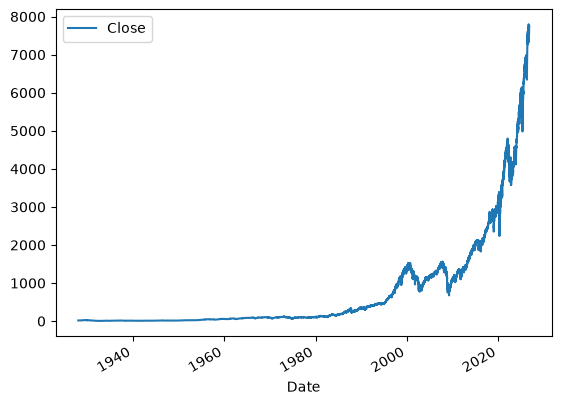

In [8]:
sp500.plot.line(y="Close", use_index = True)

In [9]:

del sp500["Stock Splits"]

In [10]:
sp500.columns


Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends'], dtype='str')

In [11]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [12]:
sp500

,Open,High,Low,Close,Volume,Dividends,Tomorrow
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,17.500000
...,...,...,...,...,...,...,...
2026-09-21 00:00:00-04:00,7692.830078,7779.220215,7691.189941,7764.700195,4828050000,0.0,7764.640137
2026-09-22 00:00:00-04:00,7770.810059,7782.189941,7756.259766,7764.640137,5286270000,0.0,7706.029785
2026-09-23 00:00:00-04:00,7761.939941,7761.939941,7694.890137,7706.029785,5110910000,0.0,7704.129883


In [13]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

In [14]:
sp500

,Open,High,Low,Close,Volume,Dividends,Tomorrow,Target
Date,,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,17.500000,0
...,...,...,...,...,...,...,...,...
2026-09-21 00:00:00-04:00,7692.830078,7779.220215,7691.189941,7764.700195,4828050000,0.0,7764.640137,0
2026-09-22 00:00:00-04:00,7770.810059,7782.189941,7756.259766,7764.640137,5286270000,0.0,7706.029785,0
2026-09-23 00:00:00-04:00,7761.939941,7761.939941,7694.890137,7706.029785,5110910000,0.0,7704.129883,0


In [15]:
sp500 = sp500.loc["2020-01-01":"2026-08-30"].copy()

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=100,
    random_state=1
)
train = sp500.iloc[:-100]
test = sp500.iloc[-100:]
predictors = ["Close","Volume","Open","High","Low"]
model.fit(train[predictors],train["Target"])


,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

In [17]:
from sklearn.metrics import precision_score
preds = model.predict(test[predictors])

In [18]:
import pandas as pd
preds = pd.Series(preds, index = test.index)

In [19]:
precision_score(test["Target"],preds)

0.75

In [20]:
preds

Date
2026-04-08 00:00:00-04:00    1
2026-04-09 00:00:00-04:00    1
2026-04-10 00:00:00-04:00    1
2026-04-13 00:00:00-04:00    1
2026-04-14 00:00:00-04:00    0
                            ..
2026-08-24 00:00:00-04:00    0
2026-08-25 00:00:00-04:00    0
2026-08-26 00:00:00-04:00    0
2026-08-27 00:00:00-04:00    0
2026-08-28 00:00:00-04:00    0
Length: 100, dtype: int64

In [21]:
test["Target"]


Date
2026-04-08 00:00:00-04:00    1
2026-04-09 00:00:00-04:00    0
2026-04-10 00:00:00-04:00    1
2026-04-13 00:00:00-04:00    1
2026-04-14 00:00:00-04:00    1
                            ..
2026-08-24 00:00:00-04:00    1
2026-08-25 00:00:00-04:00    0
2026-08-26 00:00:00-04:00    1
2026-08-27 00:00:00-04:00    0
2026-08-28 00:00:00-04:00    0
Name: Target, Length: 100, dtype: int64

In [22]:
pd.crosstab(test["Target"], preds)

col_0,0,1
Target,,
0,44,1
1,52,3


In [23]:
def predict(train, test, predictors, model):
    model.fit(train[predictors],train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index = test.index, name = "Predictions")
    combined = pd.concat([test["Target"],preds], axis = 1)
    return combined
    

In [24]:
def backtest(data, model, predictors, start = 1000, step = 250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train,test,predictors,model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)
    

In [25]:
predictions = backtest(sp500,model,predictors)

In [26]:
predictions["Predictions"].value_counts()

Predictions
0    529
1    144
Name: count, dtype: int64

In [27]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5833333333333334

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score

# Create Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

# Train the model using your existing train/test structure
log_model.fit(train[predictors], train["Target"])

# Make predictions
log_preds = log_model.predict(test[predictors])

# Calculate metrics
log_accuracy = accuracy_score(test["Target"], log_preds)
log_precision = precision_score(test["Target"], log_preds)

print("Logistic Regression")
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)

Logistic Regression
Accuracy: 0.55
Precision: 0.55


In [29]:
print("Random Forest")
print("Accuracy:", accuracy_score(test["Target"], preds))
print("Precision:", precision_score(test["Target"], preds))

print("\nLogistic Regression")
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)

Random Forest
Accuracy: 0.47
Precision: 0.75

Logistic Regression
Accuracy: 0.55
Precision: 0.55


In [30]:
# Create additional features

sp500["MA5"] = sp500["Close"].rolling(5).mean()
sp500["MA20"] = sp500["Close"].rolling(20).mean()

sp500["Daily_Return"] = sp500["Close"].pct_change()

# Remove rows with missing values created by rolling calculations
sp500 = sp500.dropna()

In [31]:
predictors = [
    "Close",
    "Volume",
    "Open",
    "High",
    "Low",
    "MA5",
    "MA20",
    "Daily_Return"
]

In [32]:
print(predictors)

['Close', 'Volume', 'Open', 'High', 'Low', 'MA5', 'MA20', 'Daily_Return']


In [33]:
sp500["MA5"] = sp500["Close"].rolling(5).mean()
sp500["MA20"] = sp500["Close"].rolling(20).mean()
sp500["Daily_Return"] = sp500["Close"].pct_change()

sp500 = sp500.dropna()

In [34]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

In [35]:
train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

In [36]:
from sklearn.metrics import accuracy_score, precision_score

# Random Forest backtest
rf_predictions = backtest(sp500, model, predictors)

print("Random Forest Backtest")
print("Accuracy:", accuracy_score(
    rf_predictions["Target"],
    rf_predictions["Predictions"]
))
print("Precision:", precision_score(
    rf_predictions["Target"],
    rf_predictions["Predictions"]
))

Random Forest Backtest
Accuracy: 0.48346456692913387
Precision: 0.5700483091787439


In [37]:
# Logistic Regression backtest

log_model = LogisticRegression(max_iter=1000)

log_predictions = backtest(
    sp500,
    log_model,
    predictors
)

print("Logistic Regression Backtest")
print("Accuracy:", accuracy_score(
    log_predictions["Target"],
    log_predictions["Predictions"]
))
print("Precision:", precision_score(
    log_predictions["Target"],
    log_predictions["Predictions"]
))

Logistic Regression Backtest
Accuracy: 0.5622047244094488
Precision: 0.5622047244094488


In [38]:
%pip install xgboost


   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   - -------------------------------------- 1.6/48.9 MB 8.6 MB/s eta 0:00:06
   --- ------------------------------------ 4.2/48.9 MB 10.5 MB/s eta 0:00:05
   ---- ----------------------------------- 5.2/48.9 MB 9.1 MB/s eta 0:00:05
   ---- ----------------------------------- 5.8/48.9 MB 7.7 MB/s eta 0:00:06
   ----- ---------------------------------- 6.8/48.9 MB 6.5 MB/s eta 0:00:07
   ------ --------------------------------- 7.9/48.9 MB 6.3 MB/s eta 0:00:07
   ------- -------------------------------- 8.9/48.9 MB 6.2 MB/s eta 0:00:07
   -------- ------------------------------- 10.0/48.9 MB 6.0 MB/s eta 0:00:07
   -------- ------------------------------- 10.7/48.9 MB 5.8 MB/s eta 0:00:07
   --------- ------------------------------ 11.8/48.9 MB 5.6 MB/s eta 0:00:07
   ---------- ----------------------------- 12.6/48.9 MB 5.6 MB/s eta 0:00:07
   ----------- ---------------------------- 13.9/48.9 MB 5.6 MB/s eta 0:00:07


In [39]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=1,
    eval_metric="logloss"
)

In [40]:
xgb_predictions = backtest(
    sp500,
    xgb_model,
    predictors
)

print("XGBoost Backtest")
print("Accuracy:", accuracy_score(
    xgb_predictions["Target"],
    xgb_predictions["Predictions"]
))
print("Precision:", precision_score(
    xgb_predictions["Target"],
    xgb_predictions["Predictions"]
))

XGBoost Backtest
Accuracy: 0.47716535433070867
Precision: 0.5609756097560976


In [41]:
# Create features using only information available at the end of each day

sp500["MA5"] = sp500["Close"].rolling(window=5).mean()
sp500["MA20"] = sp500["Close"].rolling(window=20).mean()
sp500["Daily_Return"] = sp500["Close"].pct_change()

# Target: will tomorrow's closing price be higher than today's?
sp500["Tomorrow"] = sp500["Close"].shift(-1)
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

# Remove rows with missing feature values
sp500 = sp500.dropna()

predictors = [
    "Close",
    "Volume",
    "Open",
    "High",
    "Low",
    "MA5",
    "MA20",
    "Daily_Return"
]

In [42]:
# Split data chronologically
# Last 100 trading days = test data

train = sp500.iloc[:-100].copy()
test = sp500.iloc[-100:].copy()

print("Training data:", train.shape)
print("Test data:", test.shape)

Training data: (1515, 11)
Test data: (100, 11)


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=10,
    random_state=1
)

# Train
rf_model.fit(train[predictors], train["Target"])

# Predict on unseen test data
rf_test_preds = rf_model.predict(test[predictors])

# Evaluate
rf_accuracy = accuracy_score(test["Target"], rf_test_preds)
rf_precision = precision_score(test["Target"], rf_test_preds)

print("Random Forest")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)


Random Forest
Accuracy: 0.47
Precision: 0.8


In [44]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(train[predictors], train["Target"])

log_test_preds = log_model.predict(test[predictors])

log_accuracy = accuracy_score(test["Target"], log_test_preds)
log_precision = precision_score(test["Target"], log_test_preds)

print("Logistic Regression")
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)

Logistic Regression
Accuracy: 0.56
Precision: 0.56


In [45]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=1,
    eval_metric="logloss"
)

xgb_model.fit(train[predictors], train["Target"])

xgb_test_preds = xgb_model.predict(test[predictors])

xgb_accuracy = accuracy_score(test["Target"], xgb_test_preds)
xgb_precision = precision_score(test["Target"], xgb_test_preds)

print("XGBoost")
print("Accuracy:", xgb_accuracy)
print("Precision:", xgb_precision)

XGBoost
Accuracy: 0.48
Precision: 0.8333333333333334


In [46]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "XGBoost"],
    "Accuracy": [rf_accuracy, log_accuracy, xgb_accuracy],
    "Precision": [rf_precision, log_precision, xgb_precision]
})

results

,Model,Accuracy,Precision
0,Random Forest,0.47,0.800000
1,Logistic Regression,0.56,0.560000
2,XGBoost,0.48,0.833333


In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test["Target"],
    xgb_test_preds
)

print(cm)

[[43  1]
 [51  5]]


In [48]:
log_cm = confusion_matrix(
    test["Target"],
    log_test_preds
)

print(log_cm)

[[ 0 44]
 [ 0 56]]


In [50]:
rf_cm = confusion_matrix(
    test["Target"],
    rf_test_preds
)

print(rf_cm)


[[43  1]
 [52  4]]
